# 17 — Fraud Explainability

## Objectif

Cette étape vise à étudier les variables utilisées par le modèle
Random Forest pour différencier les dossiers présentant différents
niveaux de risque de fraude.

Le modèle final de production est un ensemble Random Forest calibré
par méthode isotonic.

TreeSHAP n'explique pas directement la totalité de cette chaîne
de calibration.

Un Random Forest explicatif utilisant les mêmes hyperparamètres
est donc entraîné sur les données 1994 afin d'analyser la logique
de la composante prédictive sous-jacente.

Cette analyse ne remplace pas l'évaluation du modèle calibré final.

Les contributions SHAP décrivent le comportement prédictif
du modèle et ne constituent pas des relations causales.

In [1]:
import pandas as pd
import numpy as np

import json
import joblib
import shap

import matplotlib.pyplot as plt

from pathlib import Path
from scipy import sparse

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestClassifier


RANDOM_STATE = 42

pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.width",
    200
)

c:\Users\user\ai-business-advisor-v2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
cwd = Path.cwd()

possible_processed_paths = [
    cwd / "data" / "processed",
    cwd / "data-science" / "data" / "processed",
    cwd.parent / "data" / "processed"
]

PROCESSED_DIR = None

for path in possible_processed_paths:

    if path.exists():

        PROCESSED_DIR = path
        break


if PROCESSED_DIR is None:

    raise FileNotFoundError(
        "Impossible de localiser data/processed"
    )


DATA_DIR = PROCESSED_DIR.parent

METADATA_DIR = (
    DATA_DIR
    / "metadata"
)

ARTIFACTS_DIR = (
    DATA_DIR.parent
    / "artifacts"
)

REPORT_DIR = (
    DATA_DIR.parent
    / "reports"
    / "models"
    / "fraud"
    / "explainability"
)

REPORT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [3]:
fraud = pd.read_csv(
    PROCESSED_DIR
    / "fraud_modeling_base.csv"
)


train_1994 = (
    fraud[
        fraud["Year"] == 1994
    ]
    .copy()
)


validation_1995 = (
    fraud[
        fraud["Year"] == 1995
    ]
    .copy()
)


print(
    "1994 :",
    train_1994.shape
)

print(
    "1995 :",
    validation_1995.shape
)

1994 : (6142, 25)
1995 : (5195, 25)


In [4]:
with open(
    METADATA_DIR
    / "feature_manifest.json",
    "r",
    encoding="utf-8"
) as f:

    feature_manifest = json.load(f)


with open(
    METADATA_DIR
    / "fraud_candidate.json",
    "r",
    encoding="utf-8"
) as f:

    candidate_config = json.load(f)


fraud_config = (
    feature_manifest[
        "fraud"
    ]
)

In [5]:
continuous_features = (
    fraud_config[
        "continuous_features"
    ]
)

ordinal_features = (
    fraud_config[
        "ordinal_features"
    ]
)

categorical_features = (
    fraud_config[
        "categorical_features"
    ]
)


features = (
    continuous_features
    +
    ordinal_features
    +
    categorical_features
)

In [6]:
X_train = (
    train_1994[
        features
    ]
    .copy()
)

y_train = (
    train_1994[
        "FraudFound_P"
    ]
    .astype(int)
)


X_validation = (
    validation_1995[
        features
    ]
    .copy()
)

In [7]:
continuous_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median",
                add_indicator=True
            )
        )
    ]
)


ordinal_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            )
        )
    ]
)


categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="constant",
                fill_value="__MISSING__"
            )
        ),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "continuous",
            continuous_pipeline,
            continuous_features
        ),
        (
            "ordinal",
            ordinal_pipeline,
            ordinal_features
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_features
        )
    ]
)

In [8]:
rf_parameters = (
    candidate_config[
        "best_parameters"
    ]
)

rf_parameters

{'n_estimators': 800,
 'min_samples_split': 5,
 'min_samples_leaf': 10,
 'max_features': 'log2',
 'max_depth': 16,
 'class_weight': None}

In [9]:
explainability_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                random_state=RANDOM_STATE,
                n_jobs=-1,
                **rf_parameters
            )
        )
    ]
)

In [10]:
explainability_model.fit(
    X_train,
    y_train
)

print(
    "✅ Random Forest explicatif entraîné."
)

✅ Random Forest explicatif entraîné.


In [11]:
FINAL_MODEL_PATH = (
    ARTIFACTS_DIR
    / "fraud_random_forest_isotonic.joblib"
)


final_calibrated_model = (
    joblib.load(
        FINAL_MODEL_PATH
    )
)


print(
    "✅ Modèle calibré final chargé."
)

✅ Modèle calibré final chargé.


In [12]:
fitted_preprocessor = (
    explainability_model
    .named_steps[
        "preprocessor"
    ]
)


fitted_rf = (
    explainability_model
    .named_steps[
        "model"
    ]
)

In [13]:
feature_names = (
    fitted_preprocessor
    .get_feature_names_out()
)


print(
    "Features après preprocessing :",
    len(feature_names)
)

Features après preprocessing : 111


In [14]:
SHAP_SAMPLE_SIZE = 2000

In [15]:
X_shap_raw = (
    X_validation
    .sample(
        n=min(
            SHAP_SAMPLE_SIZE,
            len(X_validation)
        ),
        random_state=RANDOM_STATE
    )
    .copy()
)

In [16]:
X_shap_transformed = (
    fitted_preprocessor
    .transform(
        X_shap_raw
    )
)


if sparse.issparse(
    X_shap_transformed
):

    X_shap_transformed = (
        X_shap_transformed
        .toarray()
    )


X_shap_df = pd.DataFrame(
    X_shap_transformed,
    columns=feature_names,
    index=X_shap_raw.index
)

In [17]:
explainer = shap.TreeExplainer(
    fitted_rf
)

In [18]:
raw_shap_values = (
    explainer.shap_values(
        X_shap_df
    )
)


if isinstance(
    raw_shap_values,
    list
):

    positive_shap_values = (
        raw_shap_values[1]
    )

else:

    raw_array = np.asarray(
        raw_shap_values
    )

    if raw_array.ndim == 3:

        positive_shap_values = (
            raw_array[
                :,
                :,
                1
            ]
        )

    elif raw_array.ndim == 2:

        positive_shap_values = (
            raw_array
        )

    else:

        raise ValueError(
            "Format SHAP inattendu : "
            f"{raw_array.shape}"
        )

In [19]:
expected_value = (
    explainer.expected_value
)


if isinstance(
    expected_value,
    (
        list,
        tuple,
        np.ndarray
    )
):

    expected_array = np.asarray(
        expected_value
    ).reshape(-1)

    positive_expected_value = float(
        expected_array[-1]
    )

else:

    positive_expected_value = float(
        expected_value
    )


print(
    "Expected value classe fraude :",
    positive_expected_value
)

Expected value classe fraude : 0.06666110387495938


In [20]:
shap_explanation = shap.Explanation(
    values=positive_shap_values,
    base_values=np.full(
        len(X_shap_df),
        positive_expected_value
    ),
    data=X_shap_df.values,
    feature_names=feature_names
)

In [21]:
mean_abs_shap = (
    np.abs(
        positive_shap_values
    )
    .mean(
        axis=0
    )
)


shap_importance = pd.DataFrame({
    "feature":
        feature_names,

    "mean_abs_shap":
        mean_abs_shap
}).sort_values(
    "mean_abs_shap",
    ascending=False
)

In [22]:
shap_importance.head(
    20
)

,feature,mean_abs_shap
110,categorical__BasePolicy_Liability,0.010627
108,categorical__BasePolicy_All Perils,0.009868
72,categorical__VehicleCategory_Sport,0.007060
71,categorical__VehicleCategory_Sedan,0.006962
74,categorical__VehiclePrice_20000 to 29000,0.003903
16,categorical__Month_Oct,0.002565
42,categorical__AccidentArea_Rural,0.002328
43,categorical__AccidentArea_Urban,0.002158
0,continuous__Age,0.002100
61,categorical__MonthClaimed_Nov,0.001969


In [23]:
shap_importance.to_csv(
    REPORT_DIR
    / "fraud_shap_global_importance.csv",
    index=False
)

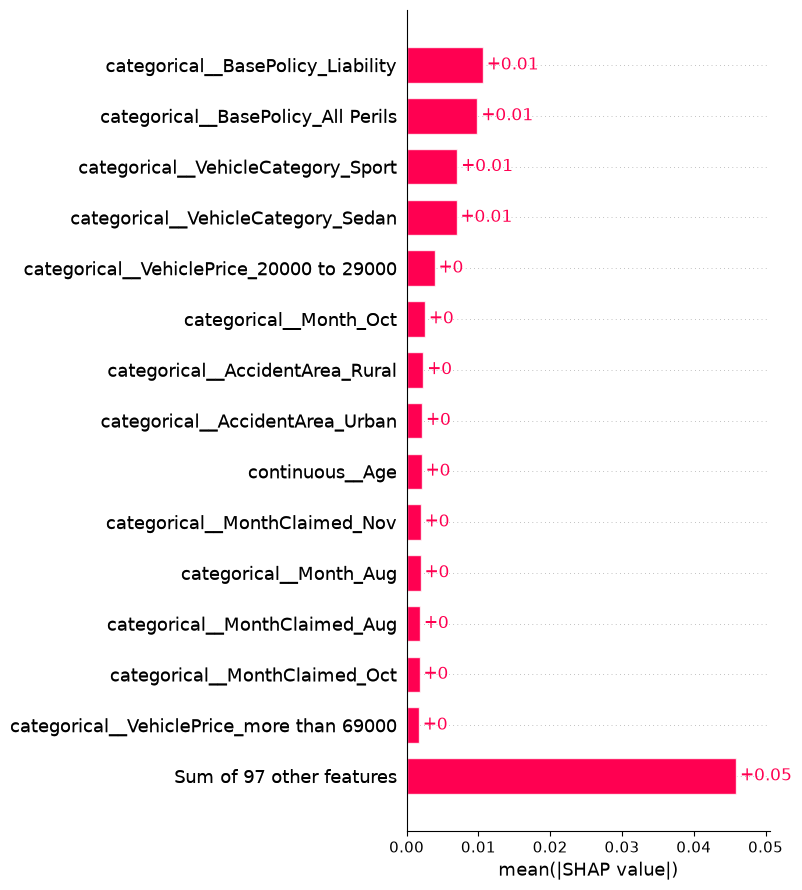

In [24]:
shap.plots.bar(
    shap_explanation,
    max_display=15,
    show=False
)

plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "fraud_shap_global_bar.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

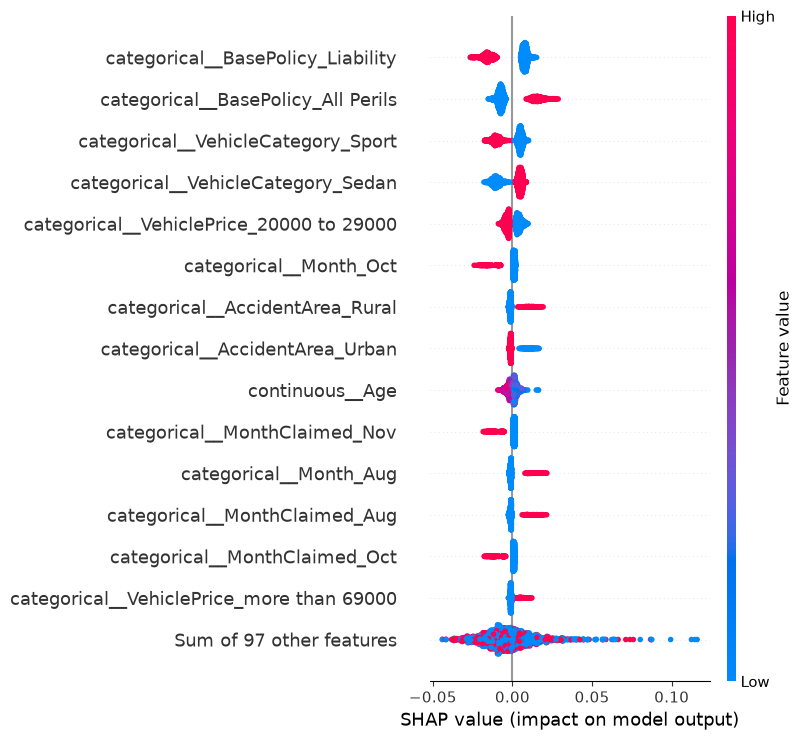

In [25]:
shap.plots.beeswarm(
    shap_explanation,
    max_display=15,
    show=False
)

plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "fraud_shap_beeswarm.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [26]:
def get_original_feature(
    feature_name
):

    if feature_name.startswith(
        "continuous__"
    ):

        cleaned = feature_name.replace(
            "continuous__",
            ""
        )

        # Les indicators ajoutés par SimpleImputer
        # peuvent avoir un nom spécifique.
        for col in continuous_features:

            if col in cleaned:

                return col

        return cleaned


    if feature_name.startswith(
        "ordinal__"
    ):

        return feature_name.replace(
            "ordinal__",
            ""
        )


    if feature_name.startswith(
        "categorical__"
    ):

        cleaned = feature_name.replace(
            "categorical__",
            ""
        )

        for col in categorical_features:

            if cleaned.startswith(
                col + "_"
            ):

                return col

        return cleaned


    return feature_name

In [27]:
shap_importance[
    "original_feature"
] = (
    shap_importance[
        "feature"
    ]
    .apply(
        get_original_feature
    )
)

In [28]:
grouped_importance = (
    shap_importance
    .groupby(
        "original_feature",
        as_index=False
    )
    .agg(
        mean_abs_shap_sum=(
            "mean_abs_shap",
            "sum"
        )
    )
    .sort_values(
        "mean_abs_shap_sum",
        ascending=False
    )
)


grouped_importance.head(
    20
)

,original_feature,mean_abs_shap_sum
5,BasePolicy,0.022134
17,VehicleCategory,0.014148
13,MonthClaimed,0.012642
12,Month,0.012056
18,VehiclePrice,0.007088
0,AccidentArea,0.004486
15,PastNumberOfClaims,0.003885
3,AgeOfVehicle,0.003865
2,AgeOfPolicyHolder,0.003219
1,Age,0.003178


In [29]:
grouped_importance.to_csv(
    REPORT_DIR
    / "fraud_shap_grouped_features.csv",
    index=False
)

In [30]:
calibrated_probabilities = (
    final_calibrated_model
    .predict_proba(
        X_shap_raw
    )[:, 1]
)


raw_rf_probabilities = (
    explainability_model
    .predict_proba(
        X_shap_raw
    )[:, 1]
)

In [31]:
highest_position = int(
    np.argmax(
        calibrated_probabilities
    )
)


lowest_position = int(
    np.argmin(
        calibrated_probabilities
    )
)

In [32]:
high_risk_case = (
    X_shap_raw
    .iloc[
        [highest_position]
    ]
)


high_raw_probability = float(
    raw_rf_probabilities[
        highest_position
    ]
)


high_calibrated_probability = float(
    calibrated_probabilities[
        highest_position
    ]
)


print(
    "Raw RF probability :",
    high_raw_probability
)

print(
    "Calibrated probability :",
    high_calibrated_probability
)

print(
    high_risk_case.T
)

Raw RF probability : 0.27728560622797976
Calibrated probability : 0.5377003003817469
                              10380
Age                             NaN
Deductible                      400
WeekOfMonth                       1
WeekOfMonthClaimed                1
DriverRating                      3
Month                           Jan
DayOfWeek                  Saturday
Make                          Honda
AccidentArea                  Rural
DayOfWeekClaimed            Tuesday
MonthClaimed                    Jan
Sex                            Male
MaritalStatus                Single
VehicleCategory               Sedan
VehiclePrice        more than 69000
PastNumberOfClaims             none
AgeOfVehicle                    new
AgeOfPolicyHolder          16 to 17
AgentType                  External
NumberOfCars              1 vehicle
BasePolicy               All Perils


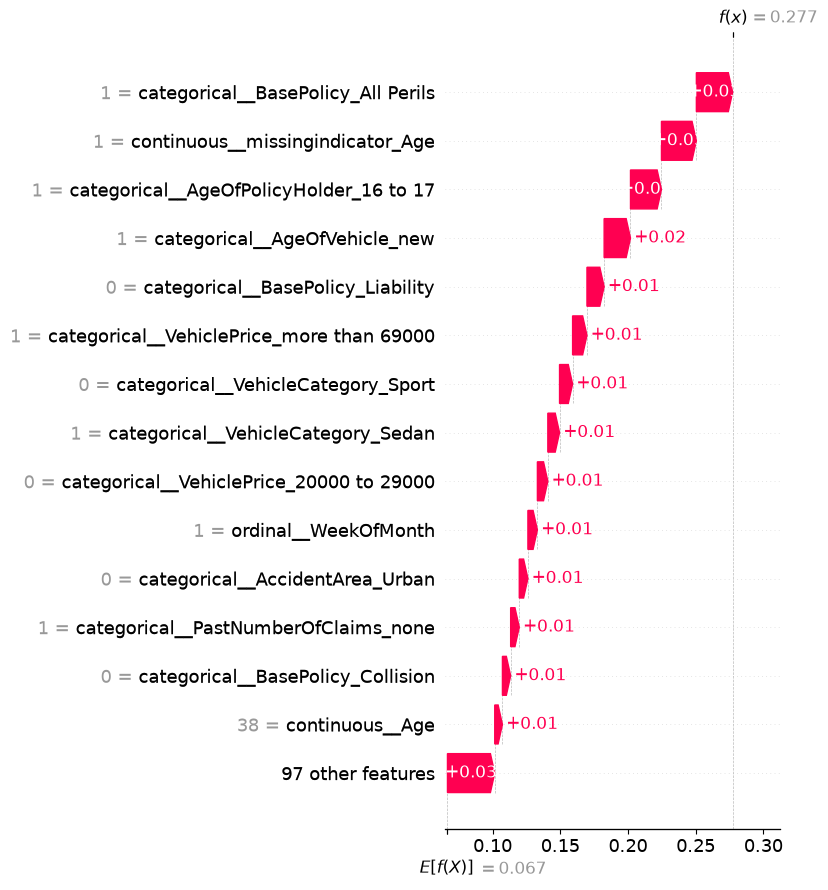

In [33]:
shap.plots.waterfall(
    shap_explanation[
        highest_position
    ],
    max_display=15,
    show=False
)

plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "fraud_shap_high_risk_waterfall.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [34]:
low_risk_case = (
    X_shap_raw
    .iloc[
        [lowest_position]
    ]
)


low_raw_probability = float(
    raw_rf_probabilities[
        lowest_position
    ]
)


low_calibrated_probability = float(
    calibrated_probabilities[
        lowest_position
    ]
)


print(
    "Raw RF probability :",
    low_raw_probability
)

print(
    "Calibrated probability :",
    low_calibrated_probability
)

print(
    low_risk_case.T
    
)

Raw RF probability : 0.006700473282560849
Calibrated probability : 0.0
                             10582
Age                           44.0
Deductible                     400
WeekOfMonth                      3
WeekOfMonthClaimed               4
DriverRating                     2
Month                          Jul
DayOfWeek                  Tuesday
Make                         Mazda
AccidentArea                 Urban
DayOfWeekClaimed         Wednesday
MonthClaimed                   Jul
Sex                           Male
MaritalStatus               Single
VehicleCategory              Sport
VehiclePrice        20000 to 29000
PastNumberOfClaims          2 to 4
AgeOfVehicle               7 years
AgeOfPolicyHolder         36 to 40
AgentType                 External
NumberOfCars             1 vehicle
BasePolicy               Liability


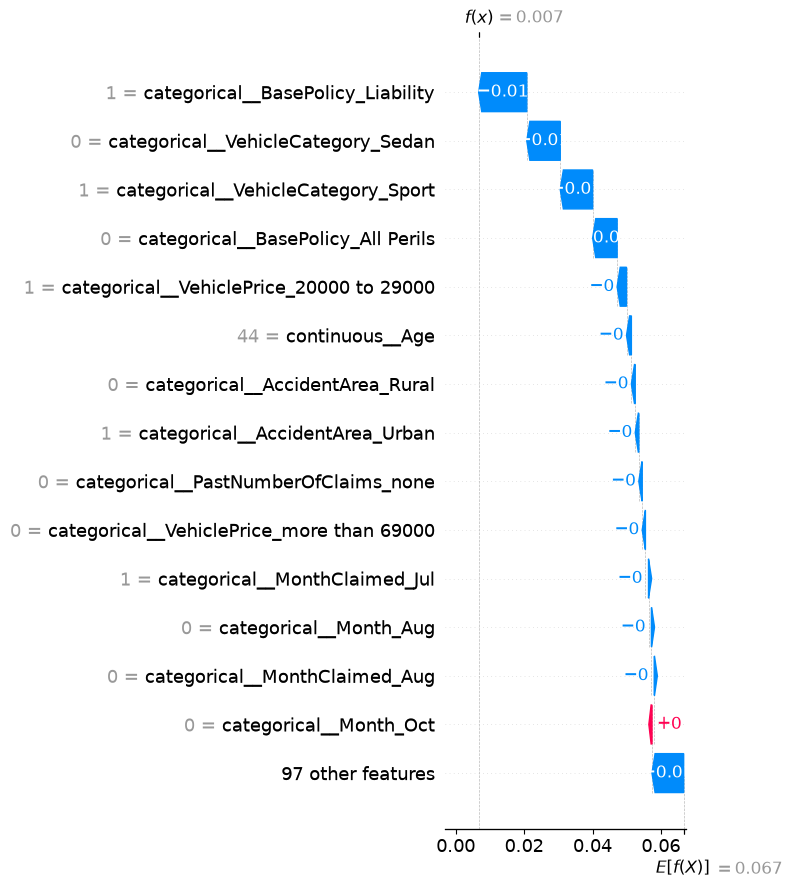

In [35]:
shap.plots.waterfall(
    shap_explanation[
        lowest_position
    ],
    max_display=15,
    show=False
)

plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "fraud_shap_low_risk_waterfall.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [36]:
low_risk_case = (
    X_shap_raw
    .iloc[
        [lowest_position]
    ]
)


low_raw_probability = float(
    raw_rf_probabilities[
        lowest_position
    ]
)


low_calibrated_probability = float(
    calibrated_probabilities[
        lowest_position
    ]
)


print(
    "Raw RF probability :",
    low_raw_probability
)

print(
    "Calibrated probability :",
    low_calibrated_probability
)

print(
    low_risk_case.T
)

Raw RF probability : 0.006700473282560849
Calibrated probability : 0.0
                             10582
Age                           44.0
Deductible                     400
WeekOfMonth                      3
WeekOfMonthClaimed               4
DriverRating                     2
Month                          Jul
DayOfWeek                  Tuesday
Make                         Mazda
AccidentArea                 Urban
DayOfWeekClaimed         Wednesday
MonthClaimed                   Jul
Sex                           Male
MaritalStatus               Single
VehicleCategory              Sport
VehiclePrice        20000 to 29000
PastNumberOfClaims          2 to 4
AgeOfVehicle               7 years
AgeOfPolicyHolder         36 to 40
AgentType                 External
NumberOfCars             1 vehicle
BasePolicy               Liability


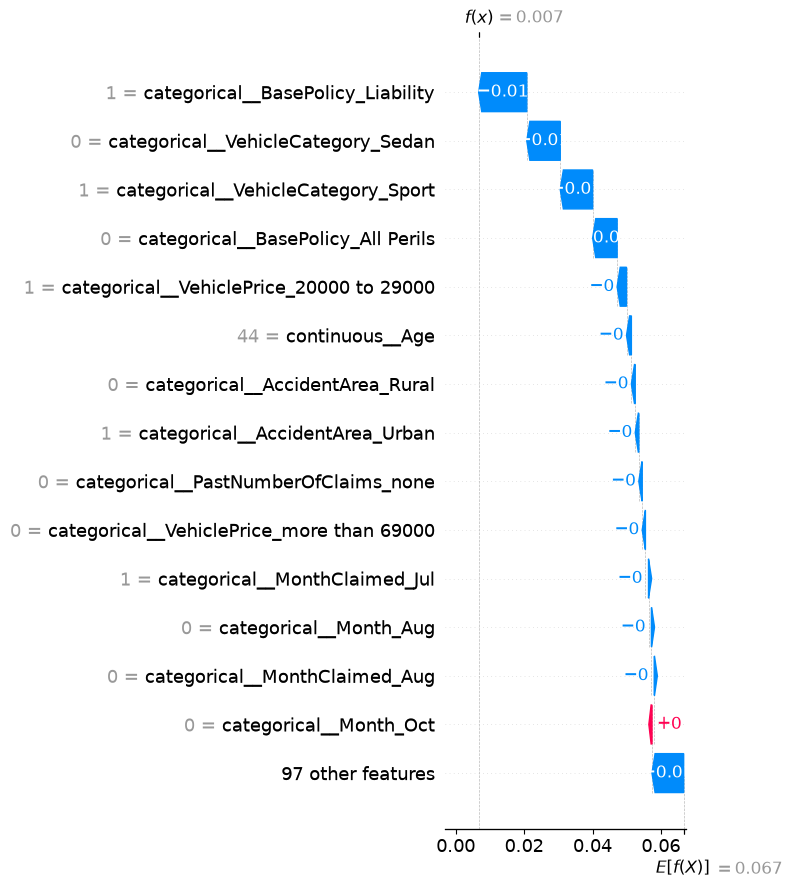

In [37]:
shap.plots.waterfall(
    shap_explanation[
        lowest_position
    ],
    max_display=15,
    show=False
)

plt.tight_layout()

plt.savefig(
    REPORT_DIR
    / "fraud_shap_low_risk_waterfall.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [38]:
print(
    "=" * 80
)

print(
    "FRAUD — SHAP RESULTS"
)

print(
    "=" * 80
)


print(
    "\n=== TOP 20 ENCODED FEATURES ==="
)

print(
    shap_importance
    .head(20)
    .round(6)
    .to_string(
        index=False
    )
)


print(
    "\n=== GROUPED BUSINESS FEATURES ==="
)

print(
    grouped_importance
    .head(20)
    .round(6)
    .to_string(
        index=False
    )
)


print(
    "\n=== HIGH RISK EXAMPLE ==="
)

print(
    "Raw RF probability :",
    high_raw_probability
)

print(
    "Calibrated probability :",
    high_calibrated_probability
)

print(
    "\nFeatures :"
)

print(
    high_risk_case
    .T
    .to_string()
)


print(
    "\n=== LOW RISK EXAMPLE ==="
)

print(
    "Raw RF probability :",
    low_raw_probability
)

print(
    "Calibrated probability :",
    low_calibrated_probability
)

print(
    "\nFeatures :"
)

print(
    low_risk_case
    .T
    .to_string()
)


print(
    "\nFigures saved in :"
)

print(
    REPORT_DIR
)


print(
    "=" * 80
)

FRAUD — SHAP RESULTS

=== TOP 20 ENCODED FEATURES ===
                                    feature  mean_abs_shap   original_feature
          categorical__BasePolicy_Liability       0.010627         BasePolicy
         categorical__BasePolicy_All Perils       0.009868         BasePolicy
         categorical__VehicleCategory_Sport       0.007060    VehicleCategory
         categorical__VehicleCategory_Sedan       0.006962    VehicleCategory
   categorical__VehiclePrice_20000 to 29000       0.003903       VehiclePrice
                     categorical__Month_Oct       0.002565              Month
            categorical__AccidentArea_Rural       0.002328       AccidentArea
            categorical__AccidentArea_Urban       0.002158       AccidentArea
                            continuous__Age       0.002100                Age
              categorical__MonthClaimed_Nov       0.001969       MonthClaimed
                     categorical__Month_Aug       0.001955              Month
          

# Analyse SHAP — Fraud Classification

## Objectif

L'explicabilité SHAP a été appliquée à un Random Forest utilisant
les mêmes hyperparamètres que la composante prédictive du modèle final.

Le modèle final complet comprend également une calibration isotonic.

L'analyse SHAP explique donc principalement le comportement
de la composante Random Forest et non directement la transformation
probabiliste effectuée par la calibration isotonic.

---

## Importance globale

Les variables originales présentant les contributions agrégées
les plus importantes sont notamment :

1. BasePolicy
2. VehicleCategory
3. MonthClaimed
4. Month
5. VehiclePrice
6. AccidentArea
7. PastNumberOfClaims
8. AgeOfVehicle
9. AgeOfPolicyHolder
10. Age

Les modalités individuelles les plus importantes comprennent notamment :

- BasePolicy = Liability ;
- BasePolicy = All Perils ;
- VehicleCategory = Sport ;
- VehicleCategory = Sedan ;
- certaines catégories de VehiclePrice ;
- certains mois d'accident ou de déclaration.

Ces résultats montrent que le modèle utilise conjointement
des informations liées :

- au contrat ;
- au véhicule ;
- à la temporalité ;
- au contexte de l'accident ;
- à l'historique ;
- au profil du conducteur.

Ces associations ne doivent pas être interprétées comme
des relations causales avec la fraude.

---

## Agrégation des variables catégorielles

Les variables catégorielles sont transformées par One-Hot Encoding.

Une variable originale telle que BasePolicy est donc représentée
par plusieurs colonnes dans le modèle.

Pour faciliter l'interprétation métier, les valeurs absolues moyennes
de SHAP ont été agrégées par variable originale.

Cette agrégation est utile comme synthèse mais doit être interprétée
avec prudence, car les variables possédant davantage de modalités
disposent également de davantage de contributions pouvant être additionnées.

---

## Exemple présentant un score élevé

Un dossier de validation obtient :

- probabilité brute Random Forest : 0.2773 ;
- probabilité après calibration isotonic : 0.5377.

Ce dossier possède notamment :

- BasePolicy = All Perils ;
- VehicleCategory = Sedan ;
- VehiclePrice = more than 69000 ;
- AccidentArea = Rural ;
- AgeOfVehicle = new ;
- AgeOfPolicyHolder = 16 to 17.

La variable Age est manquante pour cette observation.

Cette valeur manquante correspond au traitement effectué durant
le nettoyage des observations initialement codées Age = 0.

Le modèle gère cette information via l'imputation et un indicateur
de valeur manquante.

Les contributions SHAP du waterfall indiquent quelles caractéristiques
augmentent ou diminuent le score du Random Forest pour ce dossier.

---

## Exemple présentant un faible score

Un autre dossier obtient :

- probabilité brute Random Forest : 0.0067 ;
- probabilité calibrée : 0.

Il présente notamment :

- Age = 44 ;
- VehicleCategory = Sport ;
- VehiclePrice = 20000 to 29000 ;
- PastNumberOfClaims = 2 to 4 ;
- AgeOfVehicle = 7 years ;
- BasePolicy = Liability.

La différence entre les deux exemples illustre la manière dont
le modèle combine plusieurs caractéristiques pour produire
des niveaux de risque différents.

---

## Calibration et explicabilité

La calibration isotonic peut transformer fortement
la probabilité brute du Random Forest.

Par exemple :

0.2773 → 0.5377

pour un dossier présentant un score élevé.

Les valeurs SHAP ne doivent donc pas être interprétées comme
une décomposition directe de la probabilité finale calibrée.

Elles expliquent la composante Random Forest sous-jacente.

---

## Limites

Les valeurs SHAP décrivent les associations apprises par le modèle.

Elles ne permettent pas d'affirmer qu'une variable provoque la fraude.

De plus, le faible nombre d'observations frauduleuses impose
une prudence particulière dans l'interprétation des profils individuels.

Le modèle de fraude doit être utilisé comme outil de priorisation
pour une investigation humaine et non comme mécanisme automatique
d'accusation ou de rejet.